# Predictive Analysis and Explainable AI (XAI)


In [18]:
!pip install shap xgboost lightgbm seaborn matplotlib pandas numpy scikit-learn nltk

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, log_loss
import shap
import random
import nltk


pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')


## Load Data

We load both artists and tracks.

In [20]:
try:
    df_artists = pd.read_csv('../dataset/cleaned_artists.csv', sep=None, index_col=0, engine='python', encoding='utf-8')
    df_tracks = pd.read_csv('../dataset/cleaned_tracks.csv')
    print(f"Artists: {df_artists.shape}")
    print(f"Tracks: {df_tracks.shape}")
except Exception as e:
    print("Error loading data. Ensure paths are correct.", e)



Artists: (104, 11)
Tracks: (11158, 45)


## NLP Feature Engineering (TF-IDF)

We extract top 2000 characteristic words from lyrics, removing the italian stopwords (such as li, l', gli, lo, le, la, etc...) which appear many times in a corpus and do not add any meaning to the sentence. This ensures that we are capturing the dialect/slang differences between regions.


In [21]:
nltk.download("stopwords")
from nltk.corpus import stopwords

df_tracks['lyrics'] = df_tracks['lyrics'].fillna('')
italian_stop_words = stopwords.words("italian")



# TF-IDF Vectorizer
# we make max_features=2000 ensures we don't overfit, capturing common slang
tfidf = TfidfVectorizer(max_features=2000, stop_words=italian_stop_words)

print("Fitting TF-IDF on lyrics...")
tfidf_matrix = tfidf.fit_transform(df_tracks['lyrics'])

tfidf_cols = [f'tfidf_{i}' for i in range(tfidf_matrix.shape[1])]
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_cols, index=df_tracks.index)

df_tracks = pd.concat([df_tracks, df_tfidf], axis=1)

print(f"Added {len(tfidf_cols)} NLP features.")


Fitting TF-IDF on lyrics...


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dieudonne/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Added 2000 NLP features.


## Merge & Macro-Zone Definition

We then map the macro-zones based on the linguistic characteristics, capturing region(or an area) with their language influence(such as dialects or almost normal language highly used in their daily conversations and songs). Source: Domain knowledge.


Macro-zone schools distribution:
macro_zone
Milan_Drill_School         4085
Lyrical_Standard_School    3071
South_Dialect_School       2217
Roman_Slang_School         1785
Name: count, dtype: int64


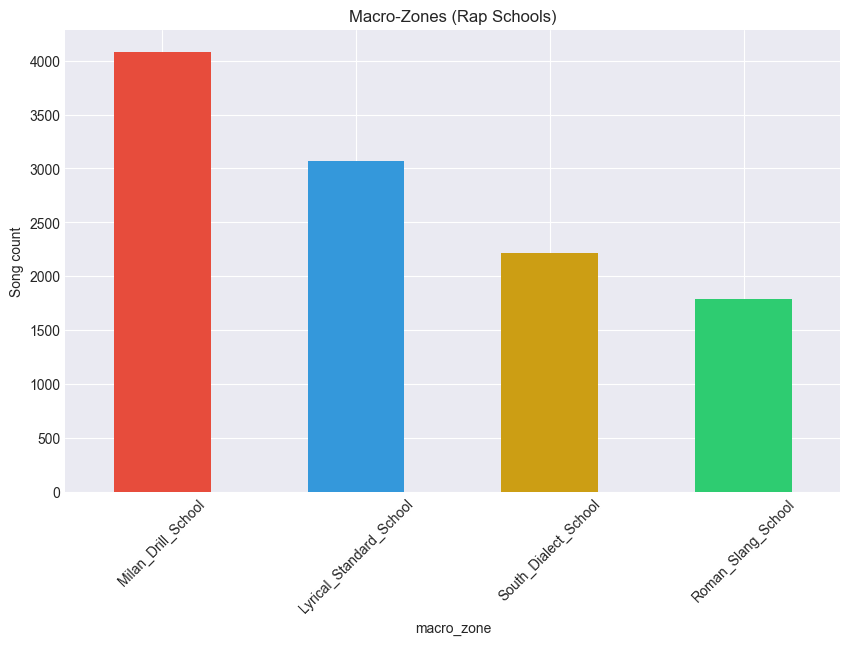

In [23]:
df_merged = pd.merge(df_tracks, df_artists, left_on='id_artist', right_index=True, how='inner')

macro_zone_mapping = {
    # Milan Drill
    'Lombardia': 'Milan_Drill_School',
    # Roman Slangs
    'Lazio': 'Roman_Slang_School',
    # South Dialects
    'Campania': 'South_Dialect_School',
    'Puglia': 'South_Dialect_School',
    'Sicilia': 'South_Dialect_School',
    'Calabria': 'South_Dialect_School',
    # Standard/Lyrical (North & Center)
    'Piemonte': 'Lyrical_Standard_School',
    'Veneto': 'Lyrical_Standard_School',
    'Liguria': 'Lyrical_Standard_School',
    'Trentino-Alto Adige': 'Lyrical_Standard_School',
    'Emilia-Romagna': 'Lyrical_Standard_School',
    'Toscana': 'Lyrical_Standard_School',
    'Marche': 'Lyrical_Standard_School',
    'Sardegna': 'Lyrical_Standard_School',
    'Umbria': 'Lyrical_Standard_School'
}

df_merged['macro_zone'] = df_merged['region'].map(macro_zone_mapping)

df_merged = df_merged.dropna(subset=['macro_zone'])

print("Macro-zone schools distribution:")
print(df_merged['macro_zone'].value_counts())

plt.figure(figsize=(10, 6))
df_merged['macro_zone'].value_counts().plot(kind='bar', color=['#e74c3c', '#3498db', "#cc9e14", '#2ecc71'])
plt.title('Macro-Zones (Rap Schools)')
plt.ylabel('Song count')
plt.xticks(rotation=45)
plt.show()


### Feature Selection

To ensure our models focus on meaningful, non-leaky information, we carefully selected input features:

- **Target:**  
  The target variable is `macro_zone`, representing the rap school or macro-region for each track.

- **Metadata Exclusion:**  
  We explicitly excluded all metadata and potentially leaky columns, such as artist IDs, names, locations, dates, and any demographic or popularity information. This prevents the model from "cheating" by using information that would not be available in a real-world prediction scenario.

- **Final Feature Set:**  
  Only numerical features not in the exclusion list are used for training. This includes engineered features (e.g., TF-IDF vectors, audio features) that are relevant for classification.

This approach ensures that our models learn from the actual content and characteristics of the tracks, not from external or identifying information.

In [24]:
target_col = 'macro_zone'
y = df_merged[target_col]

metadata_cols = [
    'id_artist', 'id_track', 'name', 'id_album', 'track_id',
    'lyrics', 'description', 'birth_place', 'nationality', 'gender', 
    'region', 'province', 'country', 'macro_zone', 'latitude', 'longitude',
    'active_start', 'active_end', 'birth_date', 'active_start_dt',
    'active_start_year', 'min_track_year',
    'month', 'day', 'popularity', 'stats_pageviews', 'modified_popularity',
    'track_number', 'disc_number', 'swear_IT_words', 'swear_EN_words', 'collab_count', 'active_start_final', 'gender_code', 'year'
]

X = df_merged.select_dtypes(include=[np.number])
cols_to_drop = [c for c in metadata_cols if c in X.columns]
X = X.drop(columns=cols_to_drop)
X = X.fillna(0)
print(f"Selected {X.shape[1]} features dynamically.")
print(f"Feature Examples: {list(X.columns)}...")


Selected 2019 features dynamically.
Feature Examples: ['swear_IT', 'swear_EN', 'n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'rms', 'zcr', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'duration_ms', 'tfidf_0', 'tfidf_1', 'tfidf_2', 'tfidf_3', 'tfidf_4', 'tfidf_5', 'tfidf_6', 'tfidf_7', 'tfidf_8', 'tfidf_9', 'tfidf_10', 'tfidf_11', 'tfidf_12', 'tfidf_13', 'tfidf_14', 'tfidf_15', 'tfidf_16', 'tfidf_17', 'tfidf_18', 'tfidf_19', 'tfidf_20', 'tfidf_21', 'tfidf_22', 'tfidf_23', 'tfidf_24', 'tfidf_25', 'tfidf_26', 'tfidf_27', 'tfidf_28', 'tfidf_29', 'tfidf_30', 'tfidf_31', 'tfidf_32', 'tfidf_33', 'tfidf_34', 'tfidf_35', 'tfidf_36', 'tfidf_37', 'tfidf_38', 'tfidf_39', 'tfidf_40', 'tfidf_41', 'tfidf_42', 'tfidf_43', 'tfidf_44', 'tfidf_45', 'tfidf_46', 'tfidf_47', 'tfidf_48', 'tfidf_49', 'tfidf_50', 'tfidf_51', 'tfidf_52', 'tfidf_53', 'tfidf_54', 'tfidf_55', 'tfidf_56', 'tfidf_57', 'tfidf_

### Label Encoding & Data Split

We encode the target classes as integers using `LabelEncoder` for compatibility with scikit-learn models.  
The dataset is then split into training and test sets (80/20), stratified to preserve class proportions.

In [ ]:

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)
print(f"Classes: {le_target.classes_}")

row_ids = X.index.to_numpy()

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y_encoded, row_ids,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


Classes: ['Lyrical_Standard_School' 'Milan_Drill_School' 'Roman_Slang_School'
 'South_Dialect_School']


We are splitting the train dataset again (to get train and validation sets) for obtaining the ones for hyperparameter tuning without attaching test dataset.(Train set and Validation set for cross validation and grid search)

In [ ]:

X_train_es, X_val_es, y_train_es, y_val_es, idx_train_es, idx_val_es = train_test_split(
    X_train, y_train, idx_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

## Model Training & Comparison

We trained and compared four models:

1. **Random Forest**  
   - A strong baseline model that handles non-linear relationships and feature interactions well.
2. **XGBoost**  
   - A powerful gradient boosting algorithm, often achieving high predictive performance, especially with structured/tabular data.
3. **LightGBM**  
   - An efficient gradient boosting framework, optimized for speed and memory usage, and particularly effective when working with a large number of features.
4. **SVM(Linear)**  
   - A strong high-dimensional baseline that often works well with TF‑IDF features; we scale inputs and use class balancing.
Each model was evaluated using cross-validation and a held-out test set to ensure robust comparison.

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.metrics import f1_score, classification_report
from sklearn.calibration import CalibratedClassifierCV

# We convert to numpy arrays to avoid XGBoost compatibility issues with pandas DataFrames
if hasattr(X_train, 'values'):
    X_train = np.ascontiguousarray(X_train.values)
    X_test = np.ascontiguousarray(X_test.values)
else:
    X_train = np.ascontiguousarray(X_train)
    X_test = np.ascontiguousarray(X_test)
    
X_train_es = np.ascontiguousarray(X_train_es.values) if hasattr(X_train_es, "values") else np.ascontiguousarray(X_train_es)
X_val_es   = np.ascontiguousarray(X_val_es.values)   if hasattr(X_val_es, "values")   else np.ascontiguousarray(X_val_es)

## Grid Search

In [ ]:

param_grids = {
    "RandomForest": {
        "n_estimators": [150, 250],
        "max_depth": [4, 6],
        "min_samples_leaf": [10, 20],
        "min_samples_split": [20],
        "max_features": ["sqrt"],
    },
    "XGBoost": {
        "n_estimators": [300],
        "learning_rate": [0.05],
        "max_depth": [2, 3],
        "min_child_weight": [10],
        "subsample": [0.7],
        "colsample_bytree": [0.7],
        "reg_alpha": [10, 50],
        "reg_lambda": [10, 20],
    },
    "LightGBM": {
        "n_estimators": [500],
        "learning_rate": [0.05],
        "num_leaves": [7, 15],
        "min_child_samples": [30, 50],
        "subsample": [0.7],
        "colsample_bytree": [0.7],
        "reg_lambda": [50, 100],
    },
    "SVC": [
        {"svc__kernel": ["linear"], "svc__C": [0.001, 0.01, 0.1], "svc__class_weight": ["balanced"]},
    ],
}


### Train Models with grid search and cross validation


In this cell, we define the base models, cross-validation, and the grid search for hyperparameter tuning. Due to lack of resources, we are using 3-fold Stratified CV.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

base_models = {
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=1, class_weight='balanced_subsample'),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss', random_state=42, n_jobs=1),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1, n_jobs=1, class_weight="balanced"),
     'SVC': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(random_state=42))
    ])
}

print("HYPERPARAMETER TUNING WITH GRID_SEARCH")

tuned_models = {}
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in base_models.items():
    print(f"\nTuning {name}...")

    grid = GridSearchCV(
        model, 
        param_grids[name], 
        cv=cv, 
        scoring='f1_macro', 
        n_jobs=-1, 
        verbose=1
    )
    grid.fit(X_train, y_train)
    
    print(f"   Best Params: {grid.best_params_}")
    print(f"   Best CV F1:  {grid.best_score_:.4f}")
    
    tuned_models[name] = grid.best_estimator_ 

HYPERPARAMETER TUNING WITH GRID_SEARCH

Tuning RandomForest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
   Best Params: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 20, 'n_estimators': 250}
   Best CV F1:  0.4899

Tuning XGBoost...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
   Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 300, 'reg_alpha': 10, 'reg_lambda': 10, 'subsample': 0.7}
   Best CV F1:  0.4918

Tuning LightGBM...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

   Best Params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'min_child_samples': 30, 'n_estimators': 500, 'num_leaves': 15, 'reg_lambda': 50, 'subsample': 0.7}
   Best CV F1:  0.5794

Tuning SVC...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
   Best Params: {'svc__C': 0.001, 'svc__class_weight': 'balanced', 'svc__kernel': 'linear'}
   Best CV F1:  0.4798


## Final training and test evaluation with early stopping 

We then train and test the models with early stopping: This ensures that the models stop the training when the loss is not reducing to avoid overfitting


In [ ]:
print("FINAL TRAINING & TEST EVALUATION")

results = {}
trained_models = {}

for name, model in tuned_models.items():
    print(f"\nTraining {name}...")
    
    if name == 'XGBoost':
        model.set_params(early_stopping_rounds=50)
        eval_set = [(X_train_es, y_train_es), (X_val_es, y_val_es)]
        model.fit(X_train_es, y_train_es, eval_set=eval_set, verbose=False)
        print(f" Stopped at epoch {model.best_iteration}")
        
    elif name == 'LightGBM':
        eval_set = [(X_train_es, y_train_es), (X_val_es, y_val_es)]
        callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=False)]
        model.fit(X_train_es, y_train_es, eval_set=eval_set, eval_metric='multi_logloss', callbacks=callbacks)
        print(f" Stopped at epoch {model.best_iteration_}")
        
    else:
        model.fit(X_train, y_train)
        
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred, average='macro')
    results[name] = f1
    trained_models[name] = model
    print(f" Test F1-Macro: {f1:.4f}")
    
    # Detailed Report
    print(f"\nClassification Report ({name}):")
    print(classification_report(y_test, y_pred, target_names=le_target.classes_))

FINAL TRAINING & TEST EVALUATION

Training RandomForest...
 Test F1-Macro: 0.5112

Classification Report (RandomForest):
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.44      0.66      0.53       614
     Milan_Drill_School       0.58      0.57      0.58       817
     Roman_Slang_School       0.54      0.52      0.53       357
   South_Dialect_School       0.74      0.28      0.41       444

               accuracy                           0.53      2232
              macro avg       0.58      0.51      0.51      2232
           weighted avg       0.57      0.53      0.52      2232


Training XGBoost...
 Stopped at epoch 299
 Test F1-Macro: 0.5107

Classification Report (XGBoost):
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.51      0.46      0.49       614
     Milan_Drill_School       0.51      0.80      0.62       817
     Roman_Slang_School       0.73      0.36      0.48      

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


 Test F1-Macro: 0.5966

Classification Report (LightGBM):
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.58      0.59      0.59       614
     Milan_Drill_School       0.63      0.65      0.64       817
     Roman_Slang_School       0.62      0.60      0.61       357
   South_Dialect_School       0.56      0.54      0.55       444

               accuracy                           0.60      2232
              macro avg       0.60      0.59      0.60      2232
           weighted avg       0.60      0.60      0.60      2232


Training SVC...
 Test F1-Macro: 0.5037

Classification Report (SVC):
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.47      0.55      0.51       614
     Milan_Drill_School       0.61      0.53      0.57       817
     Roman_Slang_School       0.48      0.50      0.49       357
   South_Dialect_School       0.45      0.45      0.45       444

               accurac


#### Optional experiment: refit boosting models using the early-stopped best iteration

After training XGBoost/LightGBM with early stopping on an internal validation split (`X_train_es`/`X_val_es`), we refit a second version of each model on the full training set (`X_train`) **using the number of trees found by early stopping**.

Goal:
- Use all training data while keeping model complexity fixed (number of trees).
- Check whether this improves generalization and probability quality (log loss) without changing the evaluation protocol (test set still used only once).

This is an additional trial and does not replace the main model selection procedure.


In [ ]:

refit_models = {}

# ---- LightGBM refit ----
if "LightGBM" in trained_models:
    lgb_es = trained_models["LightGBM"]
    best_iter = getattr(lgb_es, "best_iteration_", None)

    lgb_params = lgb_es.get_params()
    if best_iter is not None:
        lgb_params["n_estimators"] = int(best_iter)

    lgb_refit = lgb.LGBMClassifier(**lgb_params)
    lgb_refit.fit(X_train, y_train)

    refit_models["LightGBM_refit"] = lgb_refit
    print(f"LightGBM best_iteration_ (from early stopping): {best_iter}")

# ---- XGBoost refit ----
if "XGBoost" in trained_models:
    xgb_es = trained_models["XGBoost"]
    best_iter = getattr(xgb_es, "best_iteration", None) 

    xgb_params = xgb_es.get_params()
    xgb_params.pop("early_stopping_rounds", None)  

    if best_iter is not None:
        xgb_params["n_estimators"] = int(best_iter) + 1 

    xgb_refit = xgb.XGBClassifier(**xgb_params)
    xgb_refit.fit(X_train, y_train, verbose=False)

    refit_models["XGBoost_refit"] = xgb_refit
    print(f"XGBoost best_iteration (from early stopping): {best_iter}")

# ---- Evaluate the models ----
classes = np.unique(y_train)

for name, model in refit_models.items():
    y_pred_test = model.predict(X_test)
    f1 = f1_score(y_test, y_pred_test, average="macro")
    acc = accuracy_score(y_test, y_pred_test)

    proba = model.predict_proba(X_test)
    ll = log_loss(y_test, proba, labels=classes)

    results[name] = f1
    trained_models[name] = model

    print(f"{name}: Test F1={f1:.4f} | Test Acc={acc:.4f} | Test LogLoss={ll:.4f}")

LightGBM best_iteration_ (from early stopping): 500
XGBoost best_iteration (from early stopping): 299
XGBoost best_iteration (from early stopping): 299


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM_refit: Test F1=0.6040 | Test Acc=0.6089 | Test LogLoss=0.9477
XGBoost_refit: Test F1=0.5243 | Test Acc=0.5600 | Test LogLoss=1.0630


In this cell, we explore the trained models' performance metrics (train, test accuracy, macro-f1 score, and logloss)

In [41]:
from sklearn.metrics import accuracy_score, log_loss
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import clone
import pandas as pd
import numpy as np

classes = np.unique(y_train)

rows = []
for name, model in trained_models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)

    train_f1 = f1_score(y_train, y_pred_train, average="macro")
    test_f1  = f1_score(y_test,  y_pred_test,  average="macro")
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test,  y_pred_test)

    train_ll = np.nan
    test_ll  = np.nan

    if hasattr(model, "predict_proba"):
        train_ll = log_loss(y_train, model.predict_proba(X_train), labels=classes)
        test_ll  = log_loss(y_test,  model.predict_proba(X_test),  labels=classes)
    else:
        cal = CalibratedClassifierCV(estimator=clone(model), method="sigmoid", cv=3)
        cal.fit(X_train, y_train)
        train_ll = log_loss(y_train, cal.predict_proba(X_train), labels=classes)
        test_ll  = log_loss(y_test,  cal.predict_proba(X_test),  labels=classes)

    rows.append({
        "Model": name,
        "Train F1 (macro)": train_f1,
        "Test F1 (macro)": test_f1,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Train LogLoss": train_ll,
        "Test LogLoss": test_ll,
    })

metrics_df = pd.DataFrame(rows).set_index("Model").sort_values("Test F1 (macro)", ascending=False)
display(metrics_df.style.format("{:.4f}"))

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

,Train F1 (macro),Test F1 (macro),Train Acc,Test Acc,Train LogLoss,Test LogLoss
Model,,,,,,
LightGBM_refit,0.8882,0.6040,0.8853,0.6089,0.5688,0.9477
LightGBM,0.8478,0.5966,0.8466,0.6035,0.6161,0.9651
XGBoost_refit,0.5849,0.5243,0.6142,0.5600,0.9971,1.0630
RandomForest,0.5479,0.5112,0.5670,0.5300,1.2807,1.2861
XGBoost,0.5749,0.5107,0.6043,0.5448,1.0138,1.0751
SVC,0.7779,0.5037,0.7731,0.5134,0.9247,1.1510


### Learning curves
We then show the learning curves for the train(from cross-validation), validation (from cross-validation), and test results to understand the learning curve accross all results.

CV LEARNING CURVES (train vs CV validation) with comparison to the final test results


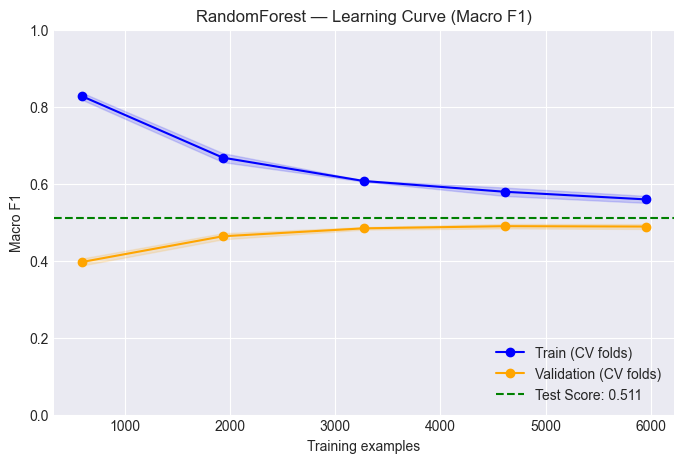

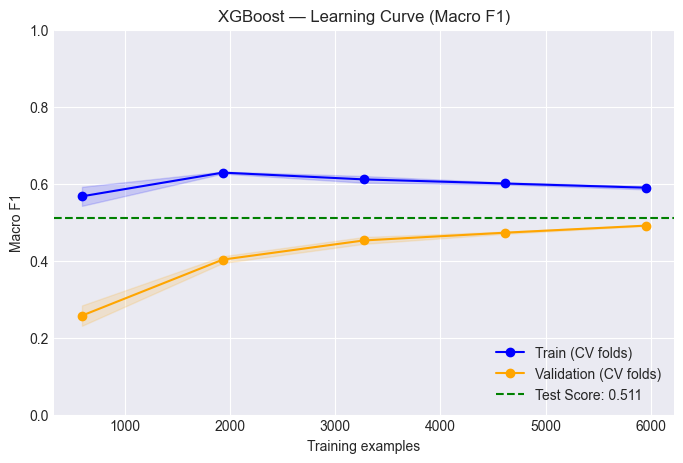

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

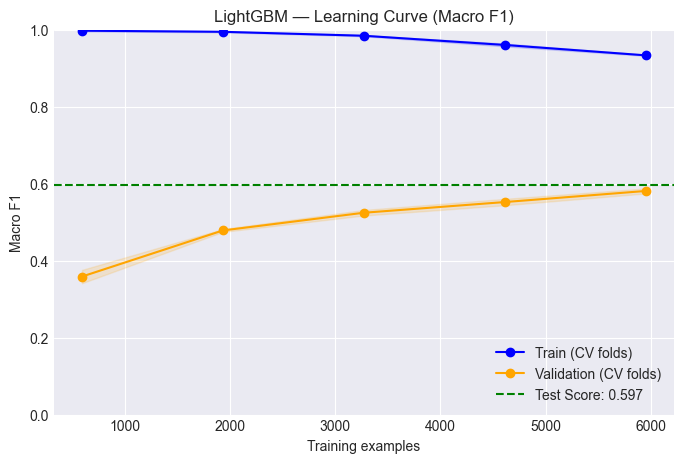

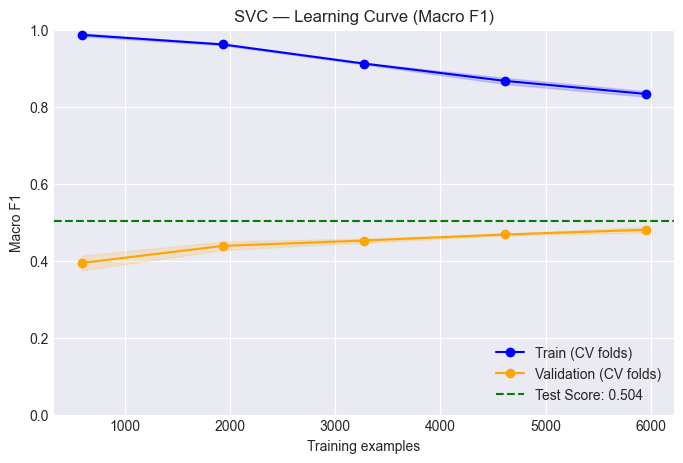

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/miniconda3/lib/pytho

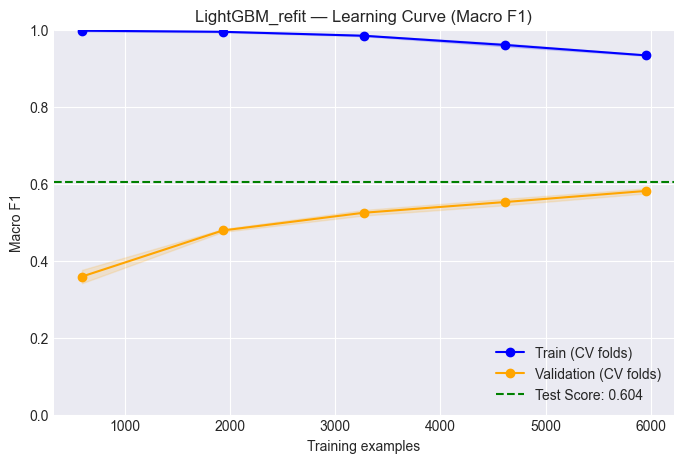

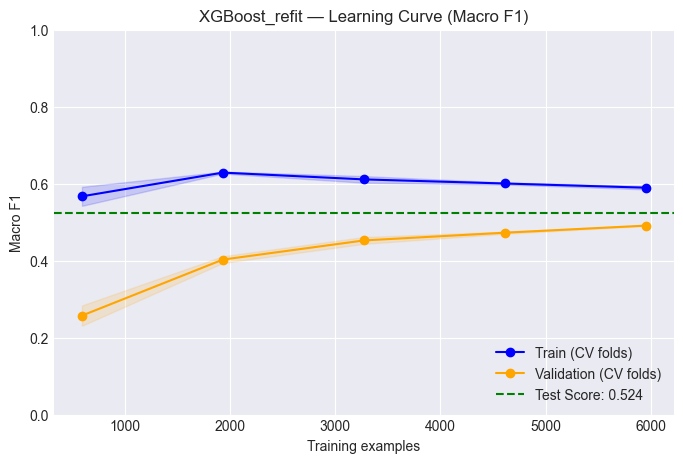

In [42]:
from sklearn.base import clone
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def _safe_estimator_for_cv(model, name):
    est = clone(model)
    if name == "XGBoost":
        try:
            est.set_params(early_stopping_rounds=None)
        except Exception:
            pass
    return est

print("CV LEARNING CURVES (train vs CV validation) with comparison to the final test results")

train_sizes = np.linspace(0.1, 1.0, 5)

models_for_curves = dict(tuned_models)
if "refit_models" in globals() and isinstance(refit_models, dict):
    models_for_curves.update(refit_models)

for name, model in models_for_curves.items():
    est = _safe_estimator_for_cv(model, name)

    sizes, train_scores, val_scores = learning_curve(
        est,
        X_train, y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        train_sizes=train_sizes
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_mean, "o-", color="blue", label="Train (CV folds)")
    plt.plot(sizes, val_mean, "o-", color="orange", label="Validation (CV folds)")
    plt.fill_between(sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="blue")
    plt.fill_between(sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="orange")

    if "results" in globals() and name in results:
        plt.axhline(
            results[name],
            color="green",
            linestyle="--",
            linewidth=1.5,
            label=f"Test Score: {results[name]:.3f}"
        )

    plt.title(f"{name} — Learning Curve (Macro F1)")
    plt.xlabel("Training examples")
    plt.ylabel("Macro F1")
    plt.ylim(0, 1.0)
    plt.grid(True)
    plt.legend(loc="lower right")
    plt.show()

## Final Results and training summary

In [43]:
# Summary with the best model of all.
print("FINAL RESULTS SUMMARY")
for name, f1 in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name}: {f1:.4f}")

best_model_name = max(results, key=results.get)
best_model = trained_models[best_model_name]
print(f"\nBest Model: {best_model_name}")

FINAL RESULTS SUMMARY
  LightGBM_refit: 0.6040
  LightGBM: 0.5966
  XGBoost_refit: 0.5243
  RandomForest: 0.5112
  XGBoost: 0.5107
  SVC: 0.5037

Best Model: LightGBM_refit


### Model comparisons plots against f1 score(macro)


/var/folders/29/j2385crd6f5dyk4l3185qktm0000gn/T/ipykernel_66634/1310178449.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


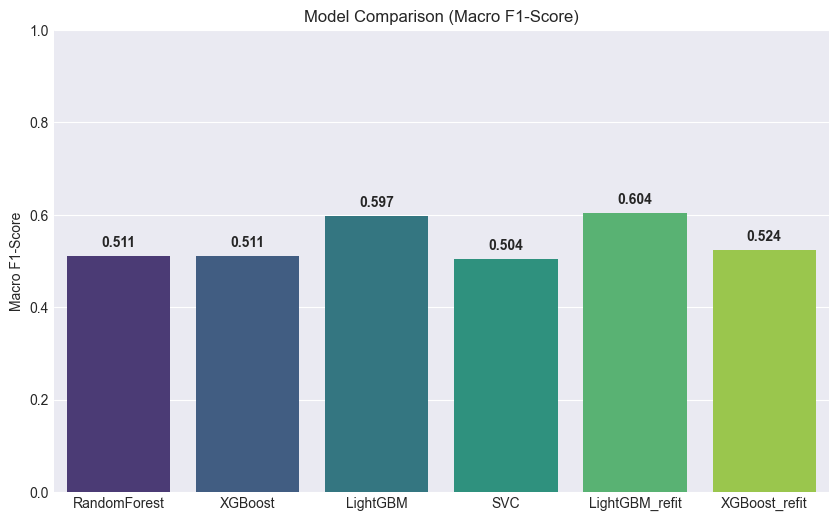


Best Model: LightGBM_refit with F1-Macro: 0.6040


In [44]:
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.title('Model Comparison (Macro F1-Score)')
plt.ylabel('Macro F1-Score')
plt.ylim(0, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()

print(f"\nBest Model: {best_model_name} with F1-Macro: {results[best_model_name]:.4f}")


### Classification report & Confusion matrix plot of the best model

/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report for LightGBM_refit:
                         precision    recall  f1-score   support

Lyrical_Standard_School       0.58      0.61      0.60       614
     Milan_Drill_School       0.64      0.63      0.64       817
     Roman_Slang_School       0.61      0.61      0.61       357
   South_Dialect_School       0.58      0.57      0.58       444

               accuracy                           0.61      2232
              macro avg       0.60      0.60      0.60      2232
           weighted avg       0.61      0.61      0.61      2232



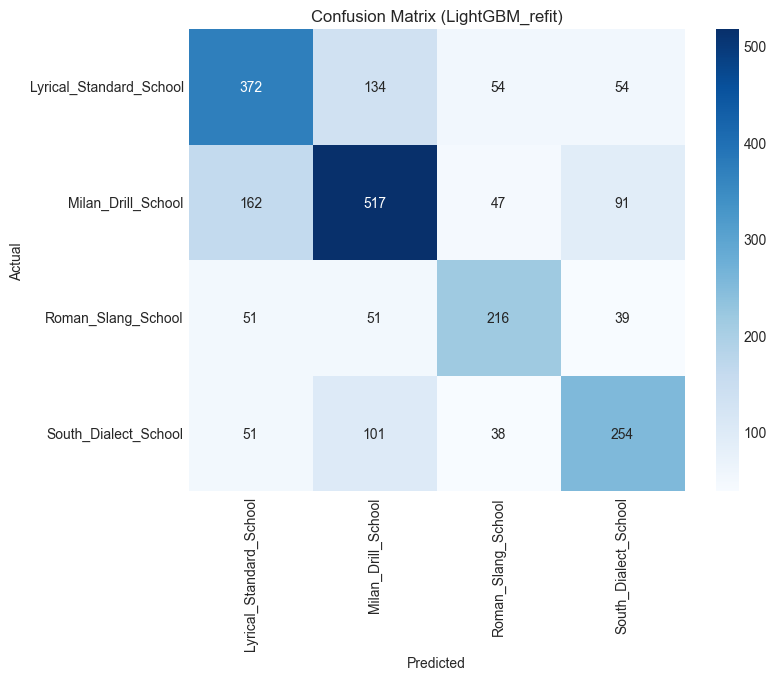

In [45]:
y_pred_best = best_model.predict(X_test)
print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=le_target.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title(f'Confusion Matrix ({best_model_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# SHAP Explainability

To interpret our model predictions, we use SHAP (SHapley Additive exPlanations):

- **Feature Mapping:**  
  We map TF-IDF feature indices back to their original words for interpretability.

- **SHAP Explainer:**  
  For tree-based models (Random Forest, XGBoost, LightGBM), we use `TreeExplainer`.  
  For other models, we use `KernelExplainer`.

- **Visualization:**  
  The SHAP summary plot shows the most important features driving the model’s predictions, making it easier to understand which words or features are most influential for each rap school class to the model.

Feature names mapped.
Original: ['tfidf_1980', 'tfidf_1981', 'tfidf_1982', 'tfidf_1983', 'tfidf_1984', 'tfidf_1985', 'tfidf_1986', 'tfidf_1987', 'tfidf_1988', 'tfidf_1989', 'tfidf_1990', 'tfidf_1991', 'tfidf_1992', 'tfidf_1993', 'tfidf_1994', 'tfidf_1995', 'tfidf_1996', 'tfidf_1997', 'tfidf_1998', 'tfidf_1999']
Mapped:   ['when', 'white', 'who', 'with', 'woo', 'wow', 'ya', 'yah', 'ye', 'yeah', 'yeh', 'yes', 'yo', 'you', 'young', 'your', 'zero', 'zio', 'zitto', 'zona']

SHAP Shape: (2232, 2019, 4)


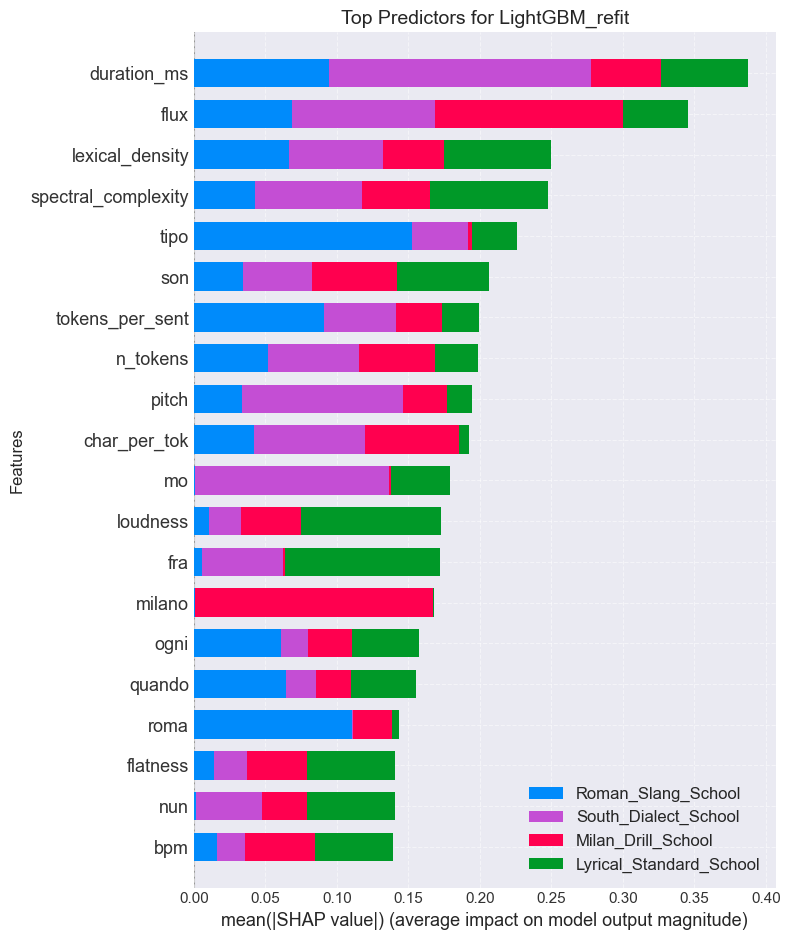

,feature,mean(|SHAP|)
0,fra,0.108575
1,loudness,0.098363
2,spectral_complexity,0.082829
3,lexical_density,0.075234
4,son,0.064572
5,flatness,0.061512
6,nun,0.061181
7,duration_ms,0.060612
8,vuoi,0.057067
9,bpm,0.054699


,feature,mean(|SHAP|)
0,milano,0.166022
1,flux,0.131446
2,marcio,0.120427
3,char_per_tok,0.065391
4,pe,0.060834
5,bro,0.059741
6,son,0.059637
7,zio,0.057000
8,ora,0.054579
9,n_tokens,0.053238


,feature,mean(|SHAP|)
0,tipo,0.152813
1,frate,0.118871
2,roma,0.110682
3,duration_ms,0.094380
4,tokens_per_sent,0.090784
5,flux,0.068852
6,n_sentences,0.066711
7,lexical_density,0.066609
8,quando,0.064449
9,adesso,0.061803


,feature,mean(|SHAP|)
0,duration_ms,0.183498
1,mo,0.135797
2,pitch,0.112422
3,flux,0.099604
4,swear_IT,0.093940
5,char_per_tok,0.077835
6,spectral_complexity,0.074642
7,centroid,0.071301
8,nu,0.066314
9,lexical_density,0.065813


In [49]:
vocab = tfidf.get_feature_names_out()
feature_mapping = {f'tfidf_{i}': word for i, word in enumerate(vocab)}
display_feature_names = [feature_mapping.get(col, col) for col in X.columns]

print("Feature names mapped.")
print(f"Original: {list(X.columns)[-20:]}")
print(f"Mapped:   {display_feature_names[-20:]}")

if any(m in best_model_name for m in ['XGBoost', 'LightGBM', 'RandomForest']):
    # For LightGBM, using the booster directly avoids the 'feature_names_in_' setter error
    model_to_explain = best_model.booster_ if 'LightGBM' in best_model_name else best_model
    explainer = shap.TreeExplainer(model_to_explain)
    shap_explanation = explainer(X_test)
else:
    explainer = shap.KernelExplainer(best_model.predict_proba, X_train[:50])
    shap_explanation = explainer(X_test)

print(f"\nSHAP Shape: {shap_explanation.shape}")

plt.figure(figsize=(12, 8))
plt.title(f"Top Predictors for {best_model_name}", fontsize=14)
plt.xlabel("SHAP values - Impact on model output", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

shap.summary_plot(
    shap_values=shap_explanation.values, 
    features=X_test,                     
    feature_names=display_feature_names, 
    class_names=le_target.classes_,      
    plot_type="bar"                     
)

shap_vals = shap_explanation.values 
if shap_vals.ndim == 3:
    import pandas as pd
    for ci, cname in enumerate(le_target.classes_):
        mean_abs = np.abs(shap_vals[:, :, ci]).mean(axis=0)
        top = np.argsort(mean_abs)[::-1][:10]
        display(pd.DataFrame({
            "feature": np.array(display_feature_names)[top],
            "mean(|SHAP|)": mean_abs[top],
        }).reset_index(drop=True))

plt.show()




### Local and Class-wise SHAP Explanations

- **Local Explanation:**  
  For a randomly selected test song, we use a SHAP waterfall plot to visualize the top features that most influenced the model’s prediction for that specific track and class.

  For each rap school class, we compute and display the top 10 most influential features (on average) across all test samples.  
  This helps identify which words or features are most characteristic for each class, providing deeper interpretability of the model’s decisions.

Analyzing Song Index: 1022
Song ID: TR475477
Artist: Dani Faiv
Song Name: Ultimo piano
Region: Liguria
Predicted Macrozone: Lyrical_Standard_School
Actual Macrozone: Lyrical_Standard_School


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


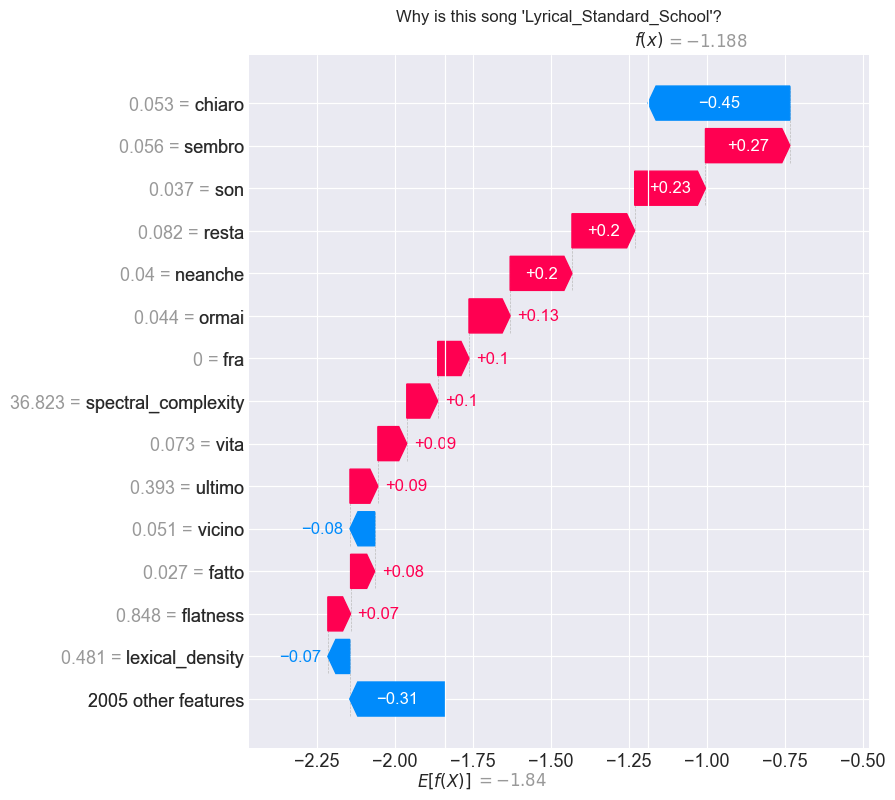

In [ ]:
idx = random.randint(0, len(X_test)-1)

prediction_code = best_model.predict(X_test[idx].reshape(1, -1))[0]
predicted_class = le_target.inverse_transform([prediction_code])[0]
actual_class = le_target.inverse_transform([y_test[idx]])[0]

original_index = idx_test[idx]
row = df_merged.loc[original_index]

song_id = row.get("id_track", row.get("id", None))
artist_name = row.get("name_artist", row.get("name", ""))
song_name = row.get("title", "")
region = row.get("region", "")

print(f"Analyzing Song Index: {idx}")
print(f"Song ID: {song_id}")
print(f"Artist: {artist_name}")
print(f"Song Name: {song_name}")
print(f"Region: {region}")
print(f"Predicted Macrozone: {predicted_class}")
print(f"Actual Macrozone: {actual_class}")

shap_slice = shap_explanation[idx, :, int(prediction_code)]
shap_slice.feature_names = display_feature_names

plt.figure(figsize=(10, 10))
plt.title(f"Why is this song '{predicted_class}'?")
# max_display=15 shows the top 15 factors pushing the prediction up (red) or down (blue)
shap.plots.waterfall(shap_slice, max_display=15, show=False)
plt.show()
